# Employee Attrition Prediction Project

 

## Objective

 

The primary objective of this project is to develop a robust machine learning model capable of accurately predicting employee attrition based on historical HR data. The model aims to identify employees who are likely to leave the organization, enabling HR teams to take proactive measures to improve retention.

 

This project also focuses on comparing multiple machine learning algorithms to determine the most effective model based on performance metrics such as Recall, F1-score, and ROC-AUC. Special emphasis is given to recall, as identifying high-risk employees is critical for minimizing business impact.

 

Additionally, the goal is to build a scalable and deployment-ready solution that can be integrated into real-world HR systems for continuous monitoring and prediction of employee attrition.

 
---

 

## Business Problem

 

Employee attrition is one of the most significant challenges faced by organizations across industries. Losing employees leads to increased recruitment costs, loss of domain knowledge, reduced productivity, and disruption in business operations.

 

In many organizations, attrition is often analyzed reactively rather than proactively. Without early detection of employees at risk of leaving, companies struggle to implement effective retention strategies, resulting in higher turnover rates and long-term operational inefficiencies.

 

This project addresses the problem by leveraging data-driven techniques to predict employee attrition behavior. By identifying high-risk employees in advance, organizations can implement targeted retention strategies such as improving work-life balance, enhancing job satisfaction, optimizing compensation structures, and reducing excessive workload.

 

Ultimately, this solution helps organizations transition from reactive to proactive HR management, improving employee engagement, reducing attrition rates, and enhancing overall organizational stability.

### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

### Loading Data

In [8]:
df = pd.read_csv(r"C:\Users\Aniket\Downloads\Capstone Projects\Employee Attrition Prediction\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


#### The dataset contains employee-related features such as age, salary, job satisfaction, and work-life balance along with attrition status.

### Basic Data Understanding 

In [3]:
df.shape

(1470, 35)

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## Data Preprocessing

- Handling missing values
- Exploratory Data Analysis
- Encoding categorical variables
- Feature scaling
- Train-test split


### Data Cleanning

In [6]:
df.drop(["EmployeeCount","EmployeeNumber","Over18","StandardHours"],axis=1,inplace=True)

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(1470, 31)

#### During data understanding step we got known there are unwanted columns in the data and we drop them because :
- **EmployeeCount** → Contains constant value (no variance), so it does not contribute to model learning  

- **StandardHours** → Same value for all records, hence no predictive importance  

- **Over18** → All entries are identical ("Yes"), providing no useful information  

- **EmployeeNumber** → Unique identifier, not relevant for predicting attrition and may introduce noise

### Exploratory Data Analysis (EDA)

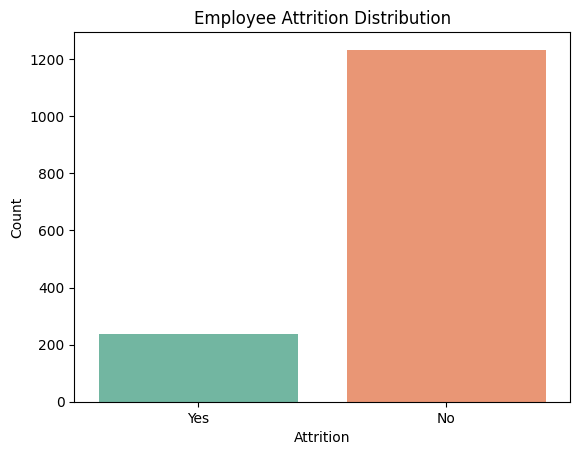

In [10]:
sns.countplot(data=df,x="Attrition",palette="Set2")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

#### Insight : The dataset is highly imbalanced, with significantly more employees staying than leaving. This indicates the need for techniques like SMOTE or class weighting to improve model performance on minority class prediction.

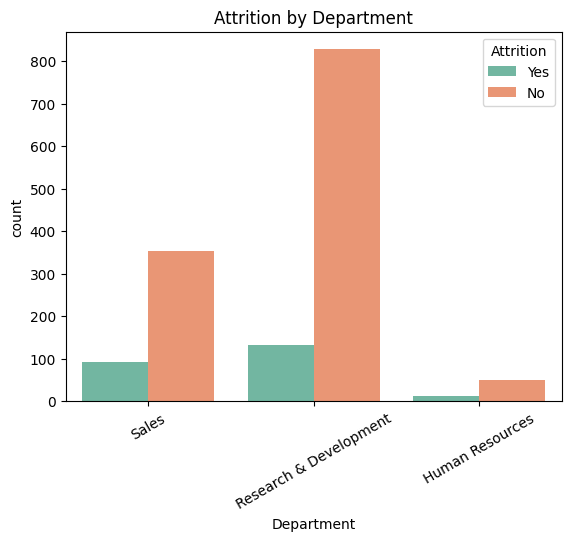

In [11]:
plt.figure()
sns.countplot(data=df,x="Department",hue="Attrition",palette="Set2")
plt.title("Attrition by Department")
plt.xticks(rotation=30)
plt.show()

#### Insight : The majority of attrition occurs in Sales and Research & Development departments. This suggests role-specific pressure, performance targets, or workload may be influencing employee turnover.

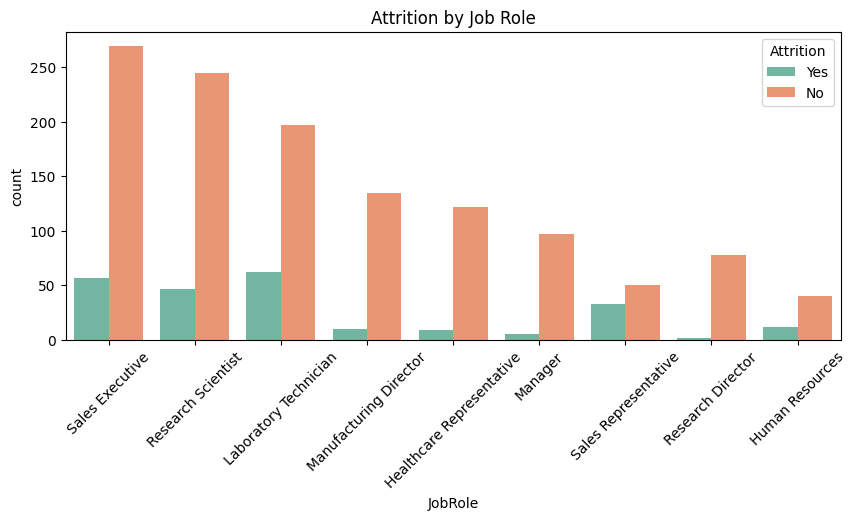

In [12]:
plt.figure(figsize=(10,4))
sns.countplot(data=df,x="JobRole",hue="Attrition",palette="Set2")
plt.title("Attrition by Job Role")
plt.xticks(rotation=45)
plt.show()

#### Insight : Roles such as Sales Executive and Laboratory Technician show higher attrition counts. This indicates that operational or target-driven roles may have higher stress and lower retention.

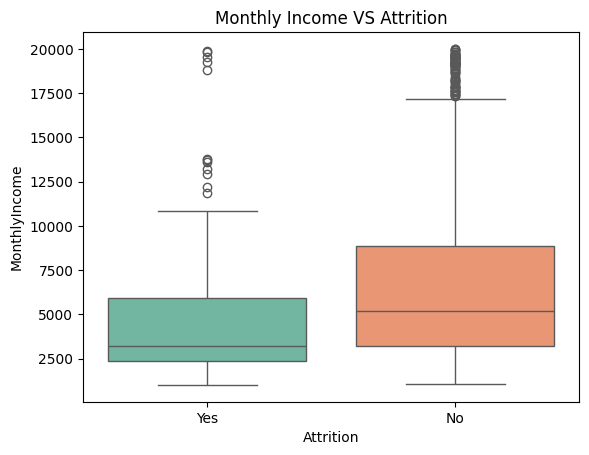

In [13]:
plt.figure()
sns.boxplot(data=df,x="Attrition",y="MonthlyIncome",palette="Set2")
plt.title("Monthly Income VS Attrition")
plt.show()

#### Insight : Employees who left tend to have lower median salaries compared to those who stayed. This highlights compensation as a key factor influencing employee retention decisions.

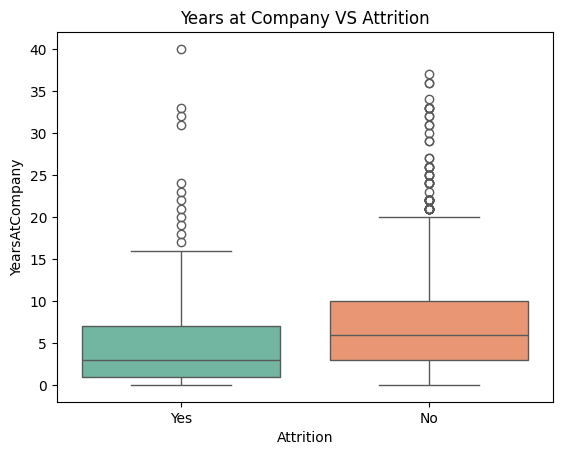

In [14]:
plt.figure()
sns.boxplot(data=df,x="Attrition",y="YearsAtCompany",palette="Set2")
plt.title("Years at Company VS Attrition")
plt.show()

#### Insight : Attrition is higher among employees with fewer years at the company. This suggests that early-stage employees are more likely to leave due to lack of engagement or better opportunities.

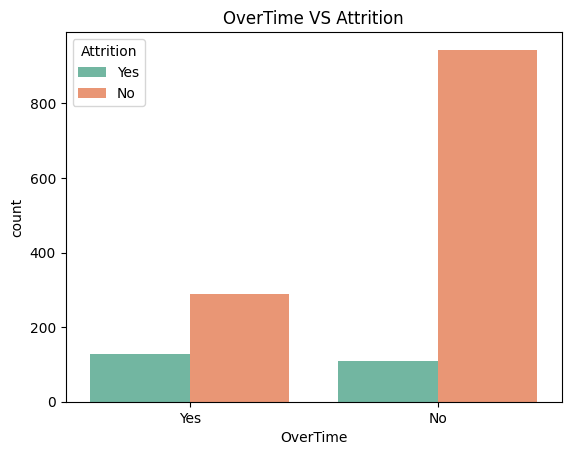

In [15]:
plt.figure()
sns.countplot(data=df,x="OverTime",hue="Attrition",palette="Set2")
plt.title("OverTime VS Attrition")
plt.show()

#### Insight : Employees working overtime show a higher likelihood of leaving compared to those who do not. This indicates workload and work-life imbalance as a major driver of attrition.

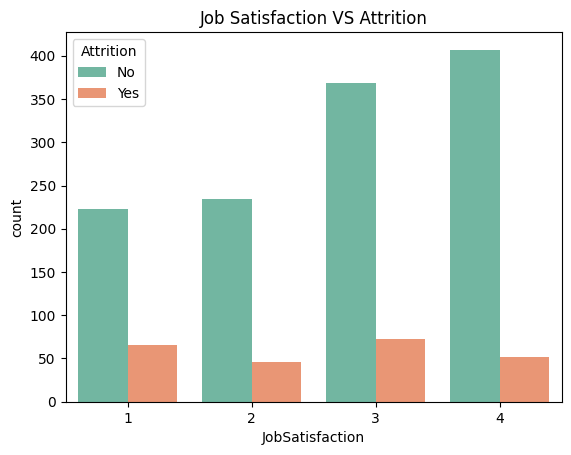

In [16]:
plt.figure()
sns.countplot(data=df,x="JobSatisfaction",hue="Attrition",palette="Set2")
plt.title("Job Satisfaction VS Attrition")
plt.show()

#### Insight : Employees with lower job satisfaction levels are more likely to leave the organization. Higher satisfaction levels are strongly associated with better employee retention.

## Feature Engineering

### Assigning Target Variable

In [17]:
x = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [18]:
y = y.map({"Yes": 1, "No": 0})

### Train-Test-Split

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### Model Training & Evaluation

In this project, multiple machine learning models were trained and evaluated to predict employee attrition effectively. The objective was not only to achieve high accuracy but also to ensure model robustness, generalization, and stability across different data splits.

#### Approach
A structured approach was followed:

 - Multiple classification models were selected, including:

  - Logistic Regression
  - Support Vector Machine (SVM) 
  - K-Nearest Neighbors (KNN)  
  - Decision Tree  
  - Random Forest  
  - Gradient Boosting models (XGBoost / LightGBM)  

  - Instead of selecting a model directly, all models were evaluated using a consistent pipeline-based framework.

---

#### Use of Pipeline

A machine learning pipeline was implemented to streamline preprocessing and model training.

 - The pipeline includes:

  - ColumnTransformer for handling numerical and categorical features  
  - StandardScaler for feature scaling  
  - OneHotEncoder for categorical encoding  
  - SMOTE for handling class imbalance  
  - Machine learning model  

#### Why Pipeline?

- Ensures consistent preprocessing across training and testing  
- Prevents data leakage  
- Handles imbalance within cross-validation  
- Simplifies deployment process  
- Makes the workflow more structured and reproducible  

---

#### Cross-Validation Strategy

Cross-validation was applied on the training dataset to evaluate model performance.

- 5-Fold Cross Validation was used  
- Evaluation metric: ROC-AUC Score  

#### Why Cross-Validation?

- Provides a reliable estimate of model performance  
- Reduces overfitting risk  
- Ensures model stability across different data splits  

---

#### Evaluation Metrics

Models were evaluated using multiple metrics:

- Accuracy → Overall correctness  
- F1 Score → Balance between precision and recall  
- ROC-AUC Score → Model’s ability to distinguish between classes  

Additionally:

- Confusion Matrix was used for visual evaluation  
- Classification Report provided detailed performance insights  

---

#### Final Objective

The goal was to:

- Compare multiple models using a unified framework  
- Identify the most reliable model  
- Ensure the model performs well on unseen data  

This structured approach ensures that the final model is both accurate and robust for real-world deployment.

### Importing Machine Learning Libraries & Evaluation Metrics

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from sklearn.metrics import *
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

In [21]:
num_cols = x.select_dtypes(include=["int64", "float64"]).columns
cat_cols = x.select_dtypes(include=["object"]).columns
preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols),("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
smote = SMOTE(random_state=42)

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(n_estimators=200, random_state=42,verbose=-1)}


 LOGISTIC REGRESSION
CV Score: 0.8204


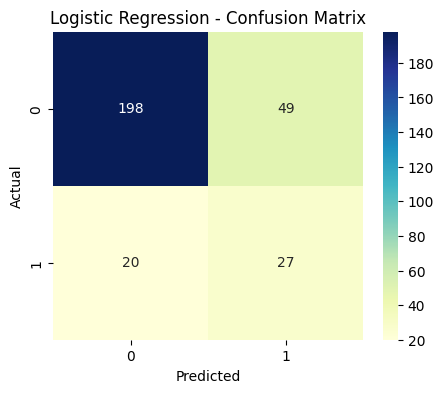

              precision    recall  f1-score   support

           0       0.91      0.80      0.85       247
           1       0.36      0.57      0.44        47

    accuracy                           0.77       294
   macro avg       0.63      0.69      0.65       294
weighted avg       0.82      0.77      0.79       294

Accuracy of the model : 0.7653061224489796
F1 Score of the model : 0.43902439024390244
ROC-AUC Score of the model : 0.7957619088638127

 SVM
CV Score: 0.7874


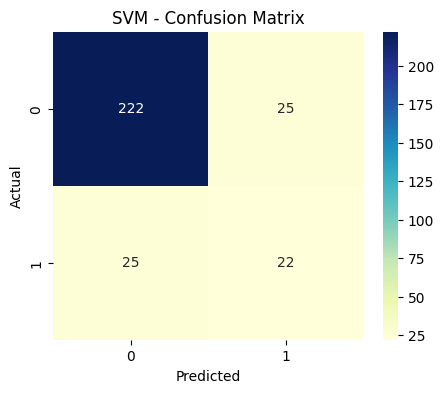

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.47      0.47      0.47        47

    accuracy                           0.83       294
   macro avg       0.68      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294

Accuracy of the model : 0.8299319727891157
F1 Score of the model : 0.46808510638297873
ROC-AUC Score of the model : 0.7582048410715824

 KNN
CV Score: 0.6802


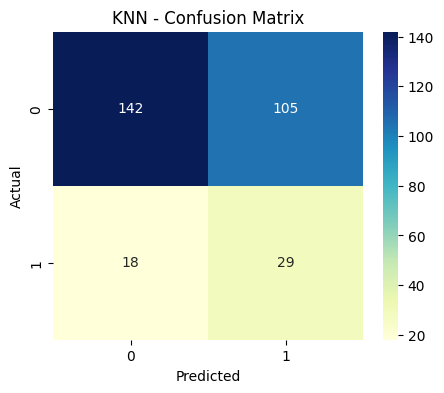

              precision    recall  f1-score   support

           0       0.89      0.57      0.70       247
           1       0.22      0.62      0.32        47

    accuracy                           0.58       294
   macro avg       0.55      0.60      0.51       294
weighted avg       0.78      0.58      0.64       294

Accuracy of the model : 0.5816326530612245
F1 Score of the model : 0.32044198895027626
ROC-AUC Score of the model : 0.6091825307950728

 DECISION TREE
CV Score: 0.6033


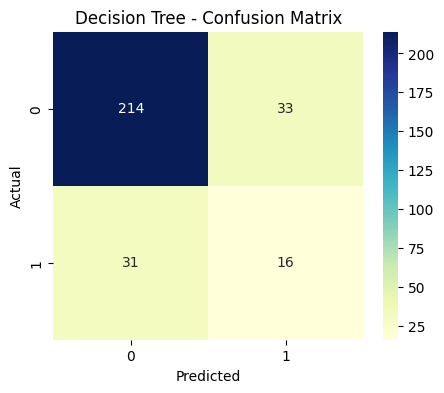

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       247
           1       0.33      0.34      0.33        47

    accuracy                           0.78       294
   macro avg       0.60      0.60      0.60       294
weighted avg       0.79      0.78      0.78       294

Accuracy of the model : 0.782312925170068
F1 Score of the model : 0.3333333333333333
ROC-AUC Score of the model : 0.6034111465242484

 RANDOM FOREST
CV Score: 0.8090


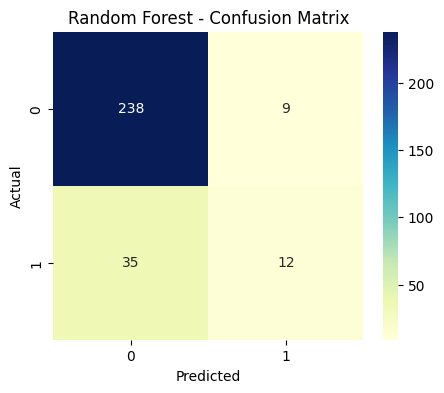

              precision    recall  f1-score   support

           0       0.87      0.96      0.92       247
           1       0.57      0.26      0.35        47

    accuracy                           0.85       294
   macro avg       0.72      0.61      0.63       294
weighted avg       0.82      0.85      0.83       294

Accuracy of the model : 0.8503401360544217
F1 Score of the model : 0.35294117647058826
ROC-AUC Score of the model : 0.8022654836764579

 XGBOOST
CV Score: 0.8003


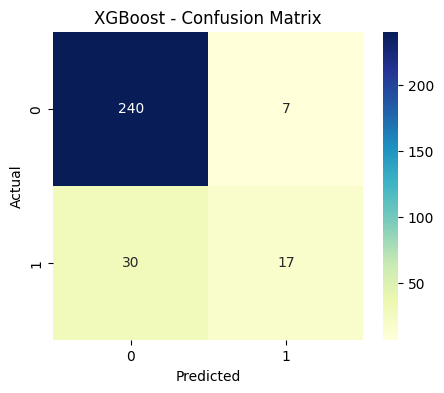

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.71      0.36      0.48        47

    accuracy                           0.87       294
   macro avg       0.80      0.67      0.70       294
weighted avg       0.86      0.87      0.86       294

Accuracy of the model : 0.8741496598639455
F1 Score of the model : 0.4788732394366197
ROC-AUC Score of the model : 0.7820656387285727

 LIGHTGBM
CV Score: 0.7955


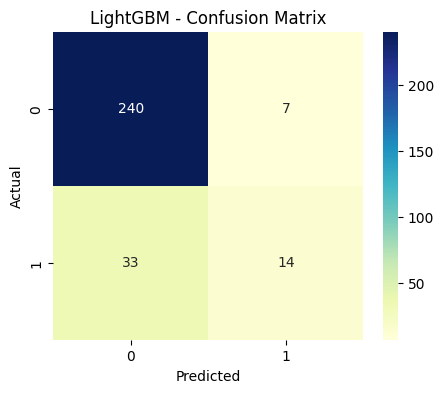

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.67      0.30      0.41        47

    accuracy                           0.86       294
   macro avg       0.77      0.63      0.67       294
weighted avg       0.85      0.86      0.84       294

Accuracy of the model : 0.8639455782312925
F1 Score of the model : 0.4117647058823529
ROC-AUC Score of the model : 0.7676802480833835


In [23]:
results = []

for name, model in models.items():
    print("\n", name.upper())

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)])
    
    cv_scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1)

    print(f"CV Score: {cv_scores.mean():.4f}")

    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)
    y_prob = pipeline.predict_proba(x_test)[:, 1]

   
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_test, y_pred))

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy of the model : {acc}")
    f1 = f1_score(y_test, y_pred)
    print(f"F1 Score of the model : {f1}")
    roc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score of the model : {roc}")
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

 ### Model Comparison

In [24]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,F1 Score,ROC-AUC
4,Random Forest,0.850340,0.352941,0.802265
0,Logistic Regression,0.765306,0.439024,0.795762
5,XGBoost,0.874150,0.478873,0.782066
6,LightGBM,0.863946,0.411765,0.767680
1,SVM,0.829932,0.468085,0.758205
2,KNN,0.581633,0.320442,0.609183
3,Decision Tree,0.782313,0.333333,0.603411


#### Multiple machine learning models were evaluated using a unified pipeline with cross-validation. Based on ROC-AUC scores, Random Forest and Logistic Regression emerged as top-performing models. These models were further optimized using GridSearchCV.

## Hyperparameter Tunning

### RANDOM FOREST

In [25]:
from sklearn.model_selection import GridSearchCV
pipeline_rf = Pipeline([("preprocessor", preprocessor),("smote", SMOTE(random_state=42)),("model", RandomForestClassifier(random_state=42))])

param_grid_rf = {"model__n_estimators": [100, 200],"model__max_depth": [None, 10, 20],"model__min_samples_split": [2, 5],
                 "model__min_samples_leaf": [1, 2]}

grid_rf = GridSearchCV(pipeline_rf,param_grid_rf,cv=5,scoring="roc_auc",n_jobs=-1)
grid_rf.fit(x_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Score:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best RF CV Score: 0.8123106566601092


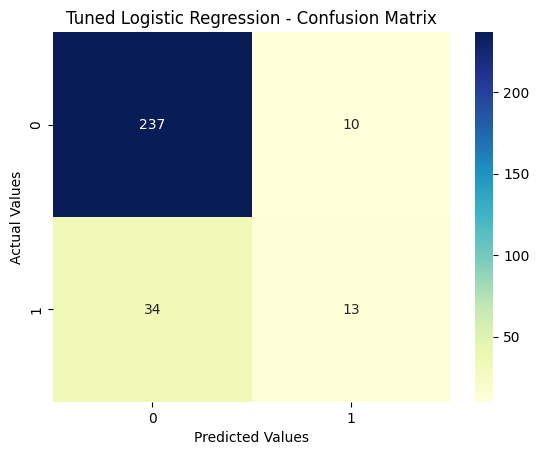

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92       247
           1       0.57      0.28      0.37        47

    accuracy                           0.85       294
   macro avg       0.72      0.62      0.64       294
weighted avg       0.83      0.85      0.83       294

Accuracy of the model: 0.8639
F1 Score of the model: 0.4118
ROC-AUC Score of the model: 0.7677


In [26]:
y_pred_best_rf = best_rf.predict(x_test)
y_prob_best_rf = best_rf.predict_proba(x_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification Report:")
print(classification_report(y_test,y_pred_best_rf))

best_rf_acc = accuracy_score(y_test,y_pred_best_rf)
best_rf_f1 = f1_score(y_test,y_pred_best_rf)
best_rf_roc = roc_auc_score(y_test,y_prob_best_rf)
print(f"Accuracy of the model: {acc:.4f}")
print(f"F1 Score of the model: {f1:.4f}")
print(f"ROC-AUC Score of the model: {roc:.4f}")

### LOGISTIC REGRESSION

In [27]:
from sklearn.model_selection import GridSearchCV
pipeline_lr = Pipeline([("preprocessor", preprocessor),("smote", SMOTE(random_state=42)),("model", LogisticRegression(max_iter=1000))])
param_grid_lr = {"model__C": [0.01, 0.1, 1, 10],
                 "model__penalty": ["l2"],
                 "model__solver": ["lbfgs", "liblinear"]}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring="roc_auc", n_jobs=-1)
grid_lr.fit(x_train, y_train)
best_lr = grid_lr.best_estimator_
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV Score: 0.8230739130552115


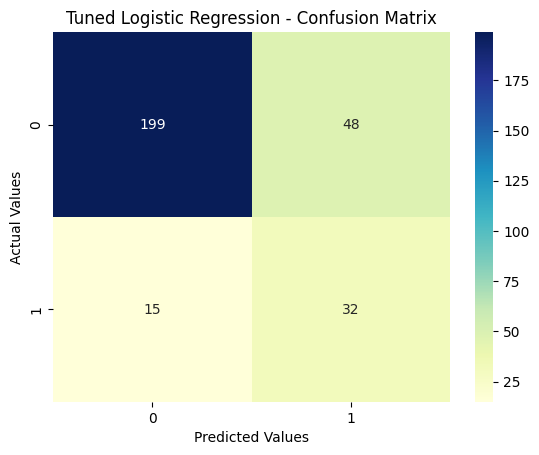

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.86       247
           1       0.40      0.68      0.50        47

    accuracy                           0.79       294
   macro avg       0.66      0.74      0.68       294
weighted avg       0.85      0.79      0.81       294

Accuracy of the model: 0.8639
F1 Score of the model: 0.4118
ROC-AUC Score of the model: 0.7677


In [28]:
y_pred_best_lr = best_lr.predict(x_test)
y_prob_best_lr = best_lr.predict_proba(x_test)[:, 1]

cm = confusion_matrix(y_test,y_pred_best_lr)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification Report:")
print(classification_report(y_test,y_pred_best_lr))

best_lr_acc = accuracy_score(y_test,y_pred_best_lr)
best_lr_f1 = f1_score(y_test,y_pred_best_lr)
best_lr_roc = roc_auc_score(y_test,y_prob_best_lr)
print(f"Accuracy of the model: {acc:.4f}")
print(f"F1 Score of the model: {f1:.4f}")
print(f"ROC-AUC Score of the model: {roc:.4f}")

#### The top-performing models, Logistic Regression and Random Forest, were further optimized using GridSearchCV.  Multiple hyperparameter combinations were evaluated using cross-validation to improve model performance and generalization.  Both tuned models were then considered for final comparison with the deep learning approach.

## Deep Learning Modle - ANN

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)
x_train_sm, y_train_sm = SMOTE().fit_resample(x_train_processed, y_train)
ann = Sequential([
    Dense(64, activation="relu", input_dim=x_train_sm.shape[1]),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")])

ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
ann.fit(x_train_sm, y_train_sm, epochs=30, batch_size=32, validation_split=0.2)
ann.summary()
y_prob_ann = ann.predict(x_test_processed)
y_pred_ann = (y_prob_ann > 0.5).astype(int)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6436 - loss: 0.6261 - val_accuracy: 0.5544 - val_loss: 0.7427
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7292 - loss: 0.5388 - val_accuracy: 0.6532 - val_loss: 0.6959
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7654 - loss: 0.5027 - val_accuracy: 0.7114 - val_loss: 0.6168
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8015 - loss: 0.4457 - val_accuracy: 0.7671 - val_loss: 0.5215
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7977 - loss: 0.4343 - val_accuracy: 0.7570 - val_loss: 0.5197
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8212 - loss: 0.4085 - val_accuracy: 0.7722 - val_loss: 0.4727
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8313 - loss: 0.3936 - val_accuracy: 0.7823 - val_loss: 0.4194
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8427 - loss: 0.3632 - val_accuracy: 0.7620 - val_loss

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           3,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,861 (69.77 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,908 (46.52 KB)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


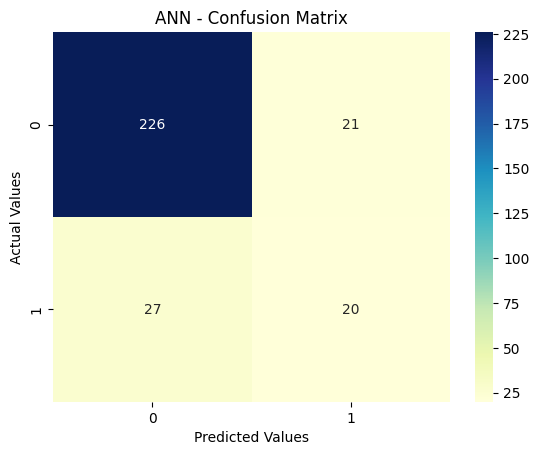

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.49      0.43      0.45        47

    accuracy                           0.84       294
   macro avg       0.69      0.67      0.68       294
weighted avg       0.83      0.84      0.83       294

Accuracy of the model: 0.8639
F1 Score of the model: 0.4118
ROC-AUC Score of the model: 0.7677


In [30]:
cm = confusion_matrix(y_test,y_pred_ann)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("ANN - Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification Report:")
print(classification_report(y_test,y_pred_ann))

ann_acc = accuracy_score(y_test,y_pred_ann)
ann_f1 = f1_score(y_test,y_pred_ann)
ann_roc = roc_auc_score(y_test,y_prob_ann)
print(f"Accuracy of the model: {acc:.4f}")
print(f"F1 Score of the model: {f1:.4f}")
print(f"ROC-AUC Score of the model: {roc:.4f}")

#### An advanced Artificial Neural Network was implemented to capture complex non-linear relationships in the data.  Multiple hidden layers with dropout regularization were used to prevent overfitting and improve generalization.  

### Final Model Comparison

In [31]:
models_dict = {
    "Tuned Logistic Regression": best_lr,
    "Tuned Random Forest": best_rf,
    "ANN": ann}

final_results = pd.DataFrame({
    "Model": ["Tuned Logistic Regression", "Tuned Random Forest", "ANN"],
    "Accuracy": [best_lr_acc,best_rf_acc, ann_acc],
    "F1 Score": [best_lr_f1,best_rf_f1, ann_f1],
    "ROC-AUC": [best_lr_roc,best_rf_roc, ann_roc]})

final_results

,Model,Accuracy,F1 Score,ROC-AUC
0,Tuned Logistic Regression,0.785714,0.503937,0.809027
1,Tuned Random Forest,0.850340,0.371429,0.795073
2,ANN,0.836735,0.454545,0.735119


In [32]:
final_results = final_results.sort_values(by="ROC-AUC", ascending=False)

best_model_name = final_results.iloc[0]["Model"]
print("Final Selected Model:", best_model_name)
best_model = models_dict[best_model_name]

Final Selected Model: Tuned Logistic Regression


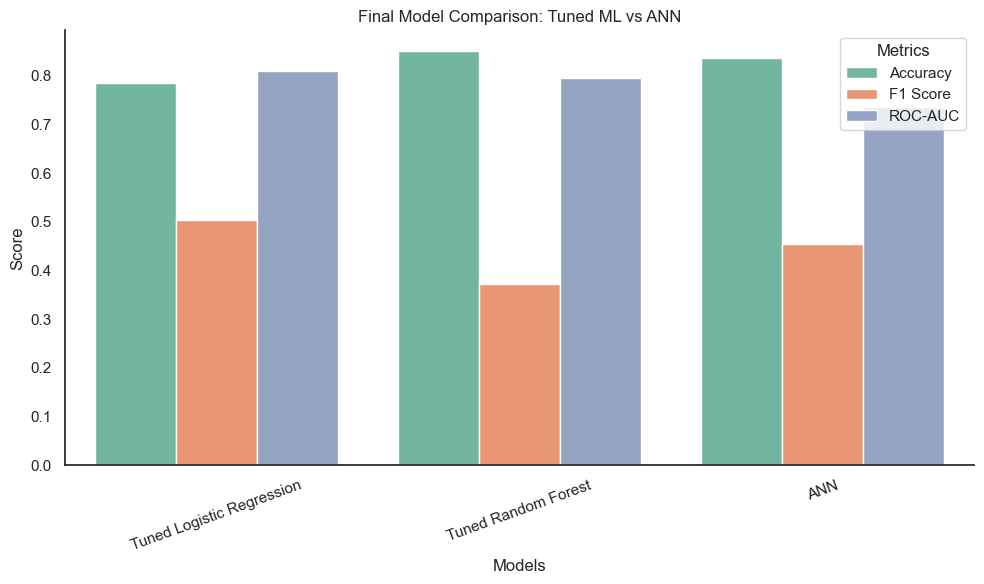

In [33]:
sns.set(style="white")
df_melted = final_results.melt(id_vars="Model",var_name="Metric",value_name="Score")
plt.figure(figsize=(10,6))
sns.barplot(data=df_melted,x="Model",y="Score",hue="Metric",palette="Set2")
plt.title("Final Model Comparison: Tuned ML vs ANN")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=20)
sns.despine()
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

#### All tuned machine learning models(Logistic Regression,Random Forest) and ANN were compared using Accuracy, F1 Score, and ROC-AUC.The final model was automatically selected based on the highest ROC-AUC score to ensure an unbiased and robust selection process.

## Model Saving

In [34]:
import joblib
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_lr.named_steps["model"])])
joblib.dump(final_pipeline, "attrition_model.pkl")

['attrition_model.pkl']

 #### Final Model Selection & Saving

All tuned models (Logistic Regression, Random Forest, and ANN) were compared using Accuracy, F1 Score, and ROC-AUC. To ensure an unbiased and robust selection process, the final model was automatically selected based on the highest ROC-AUC scorenwhich was Tuned Logistic Regression.

During model training, SMOTE was used within the pipeline to handle class imbalance. However, since SMOTE is only required during training and not during prediction, a separate deployment pipeline was created.

The final deployment pipeline includes:
- Preprocessing steps (scaling and encoding)
- The trained Logistic Regression model

SMOTE was excluded from the final pipeline to ensure correct behavior during real-time predictions.

This approach ensures:
- No data leakage
- Consistency between training and deployment
- No feature mismatch issues
- Clean and reliable predictions in production

The final pipeline was saved using the Joblib library, making it efficient to load and use during deployment.

# Conclusion
This project successfully developed a comprehensive employee attrition prediction system by integrating data preprocessing, exploratory analysis, machine learning, and deep learning techniques.The dataset initially exhibited class imbalance, which was effectively handled using SMOTE to ensure fair and unbiased model learning.

Multiple machine learning models, including Logistic Regression, KNN, Decision Tree, Random Forest, and Gradient Boosting models, were trained and evaluated using a pipeline-based approach with cross-validation. Hyperparameter tuning was applied to top-performing models (Logistic Regression and Random Forest) to further improve performance and generalization.
In addition, a deep learning model (Artificial Neural Network) was developed to capture complex non-linear relationships in the data.

All models were compared using key performance metrics such as Accuracy, F1 Score, and ROC-AUC, with special emphasis on ROC-AUC due to its reliability in imbalanced classification problems.
To ensure an unbiased and scalable solution, the final model was automatically selected based on the highest ROC-AUC score rather than manual selection. This approach improves reliability and makes the system adaptable to different datasets.

The final model was saved along with its preprocessing pipeline, ensuring consistency during deployment and eliminating feature mismatch issues.
Overall, the solution provides actionable insights into key factors influencing employee attrition and enables organizations to take proactive, data-driven decisions to improve employee retention and reduce turnover costs.